In [29]:
import jax.numpy as jnp
from scipy.stats import norm, multivariate_normal, binom, poisson
from IPython.display import Markdown, display
from jax import random
import numpy as np
import matplotlib.pyplot as plt

def to_latex_matrix(matrix):
    """Convert a JAX/numpy matrix to a LaTeX bmatrix string."""
    rows = []
    for row in matrix:
        rows.append(" & ".join(f"{val:.2f}" for val in row))
    return r"\begin{bmatrix}" + r" \\ ".join(rows) + r"\end{bmatrix}"

def to_latex_vector(vector):
    """Convert a JAX/numpy vector to a LaTeX bmatrix column vector."""
    rows = r" \\ ".join(f"{val:.2f}" for val in vector)
    return r"\begin{bmatrix}" + rows + r"\end{bmatrix}"

# Part 1

## Question 1.1

We use Bayes Rules for Gaussians:

\begin{align}
p(\bm{z}|\bm{y}) &= \mathcal{N}(\bm{z}|\bm{\mu}_{z|y}, \bm{\Sigma}_{z|y}) \\
\bm{\Sigma}_{z|y}^{-1} &= \bm{\Sigma}_z^{-1} + \mathbf{W}^\mathsf{T} \bm{\Sigma}_y^{-1} \mathbf{W} \\
\bm{\mu}_{z|y} &= \bm{\Sigma}_{z|y} \left[ \mathbf{W}^\mathsf{T} \bm{\Sigma}_y^{-1} (\bm{y} - \bm{b}) + \bm{\Sigma}_z^{-1} \bm{\mu}_z \right]
\end{align}

$$
\def\vy{\mathbf{x_{2}}}
\def\vz{\mathbf{x_{1}}}
\def\mW{\mathbf{A}}
\def\vb{\mathbf{}}
\def\vmuz{\boldsymbol{0}}
\def\vmuzly{\boldsymbol{\mu}_{z|y}}
\def\mSz{\boldsymbol{\Sigma}}
\def\mSy{\boldsymbol{\Sigma}}
\def\mSzy{\boldsymbol{\Sigma}_{z|y}}
$$

$$
\begin{align}
p(\vz|\vy) &= \mathcal{N}(\vz|\vmuzly, \mSzy) \\
\mSzy^{-1} &= \mSz^{-1} + \mW^\top \mSy^{-1} \mW \\
\vmuzly &= \mSzy \left[ \mW^\top \mSy^{-1} \vy \right]
\end{align}
$$

## Question 1.2

We begin by finding $p(x_{2})$

$$
\def\vy{\mathbf{x_{2}}}
\def\vz{\mathbf{x_{1}}}
\def\mW{\mathbf{A}}
\def\mWt{\mathbf{A}^\top}
\def\vb{\mathbf{}}
\def\vmuz{\boldsymbol{0}}
\def\vmuzly{\boldsymbol{\mu}_{z|y}}
\def\mSz{\boldsymbol{\Sigma}}
\def\mSy{\boldsymbol{\Sigma}}
\def\mSzy{\boldsymbol{\Sigma}_{z|y}}
$$

$$
p(\vy) = \int \mathcal{N}(\vz|\vmuz, \mSz)\, \mathcal{N}(\vy|\mW\vz,\, \mSy)\, d\vz 
= \mathcal{N}(\vy|\bf{0},\, \mSy + \mW\mSz\mWt)
$$

Now we can find $p(x_{3})$ we use the same rule and get:

$$p(x_{3}) = \mathcal{N}(x_{3} | 0, \Sigma + A \Sigma A^\top + AA \Sigma A^{\top} A^{\top})$$

## Question 1.3

$$
p(\mathbf{y}) = \int \mathcal{N}(\mathbf{z}|\boldsymbol{\mu}_z, \boldsymbol{\Sigma}_z)\, \mathcal{N}(\mathbf{y}|\mathbf{W}\mathbf{z} + \mathbf{b},\, \boldsymbol{\Sigma}_y)\, d\mathbf{z} 
= \mathcal{N}(\mathbf{y}|\mathbf{W}\boldsymbol{\mu}_z + \mathbf{b},\, \boldsymbol{\Sigma}_y + \mathbf{W}\boldsymbol{\Sigma}_z\mathbf{W}^\top)
$$

where $\mathcal{N}(z | \mu_{z}, \Sigma_{z}) = p(x_{2} | x_{1}) = \mathcal{N}(A x_{1}, \Sigma)$
and
$\mathcal{N}(y | W z + b, \Sigma_{y}) = p(x_{3} | x_{2}) = \mathcal{N}(A x_{2}, \Sigma)$

We get: $$p(x_{3} | x_{1}) = \mathcal{N}(x_{3} | A^{2} x_{1}, \Sigma + A \Sigma A^{\top})$$

# Part 3

## Question 3.2

In [10]:
design_matrix = lambda x: jnp.column_stack((jnp.ones(len(x)), x, x**2))
sigmoid = lambda x: 1 / (1 + jnp.exp(-x))

xstar = jnp.array([-3])
phi_star = design_matrix(xstar)

w_MAP = jnp.array([2.647, -1.688, -0.596])

f = w_MAP @ phi_star.T

sigmoid(f)

Array([0.91269547], dtype=float32)

Posterior predictive distribution for $p(y^{*} |  \bf{y}, x^{*} = 3)$ is $$\text{Ber(p = 0.91)}$$

## Question 3.3

In [11]:
norm.interval(confidence=0.9, loc = 2.647, scale = jnp.sqrt(3))

(np.float64(-0.20197000175992175), np.float64(5.49597000175992))

The $90\%$ posterior credibility interval for $w_{0}$ is 
$$p(-0.20 < w_{0} < 5.50 | y) = 0.9$$

## Question 3.4

We use the following equation to find $p(f^{*} | \bf{y}, x^{*} = -3)$:

$$p(f^{*} | \bf{y}, x^{*}) = \mathcal{N}(f^{*} | \mu, \sigma^{2})$$ where $$\mu = \phi(x^{*})^{\top} w_{MAP}$$ and $$\sigma^{2} = \phi(x^{*}) \bf{S} \phi(x^{*})^{T}$$

In [15]:
S = jnp.array([[3,-0.39,-0.3],[-0.39, 1.55, 0.37],[-0.3, 0.37, 0.14]])



mu = phi_star @ w_MAP
sigma2 = jnp.diag(phi_star @ S @ phi_star.T)

mu, sigma2

(Array([2.347], dtype=float32), Array([5.249999], dtype=float32))

We then use $$\sigma(y) \approx \Phi \left(\frac{\mu}{\sqrt{\frac{8}{\pi} + \sigma^{2}}}\right)$$ to find $p(y^{*} | \bf{y}, x^{*} = 3)$

In [17]:
probit = lambda x: norm.cdf(x)

def probit_approx(mu, sigma):
    return probit(mu / jnp.sqrt(8 / jnp.pi + sigma))

p_approx = probit_approx(mu = mu, sigma=sigma2)
p_approx

array([0.79970011])

## Question 3.5

In [21]:
p = 0.129

zero = (1-p) * 2 + p
one = (1-p) * 1 + 2*p

zero,one

(1.871, 1.129)

# Part 4

## Question 4.1

In [23]:
def compute_normal_dist_entropy(d, Sigma):
    entropy = d / 2 + d/2*jnp.log(2*jnp.pi) + 1/2 * jnp.log(jnp.linalg.det(Sigma))
    return entropy

d = 2
Sigma = jnp.eye(2)

compute_normal_dist_entropy(d = d, Sigma = Sigma)

Array(2.837877, dtype=float32)

## Question 4.2

$$\mathbb{E}_{q(w_{1},w_{2})}\left[\ln{\left(\frac{1}{\sqrt{2 \pi \sigma^{2}}} \right)} - \frac{1}{2 \sigma^{2}} (y - w_{1} w_{2})^{2}\right] = \mathbb{E}_{q(w_{1},w_{2})}\left[\ln{\left(\frac{1}{\sqrt{2 \pi \sigma^{2}}} \right)} - \frac{1}{2 \sigma^{2}} (y^{2} - 2w_{1}w_{2} + w_{1}^{2} w_{2}^{2})\right]$$

We can move the expectation inside to cover $w_{1}$ and $w_{2}$ and use:
$$\mathbb{E}[w_{1}] = m_{1}$$ $$\mathbb{E}[w_{2}] = m_{2}$$ $$\mathbb{E}[w_{1}^{2}] = m_{1}^{2} + v_{1}$$ $$\mathbb{E}[w_{2}^{2}] = m_{2}^{2} + v_{2}$$

$$\ln{\left(\frac{1}{\sqrt{2 \pi \sigma^{2}}} \right)} - \frac{1}{2 \sigma^{2}} (y^{2} - 2 \mathbb{E}[w_{1}] \mathbb{E}[w_{2}] + \mathbb{E}[w_{1}^{2}] \mathbb{E}[w_{2}^{2}])$$

$$\ln{\left(\frac{1}{\sqrt{2 \pi \sigma^{2}}} \right)} - \frac{1}{2 \sigma^{2}} (y^{2} - 2 m_{1} m_{2} + (m_{1}^{2} + v_{1}) (m_{2}^{2} + v_{2}) )$$

In [26]:
sigma = 1
v1 = 1
v2 = 1
m1 = -1
m2 = 1
y = 1

jnp.log(1/jnp.sqrt(2*jnp.pi * sigma**2)) - (1 / (2*sigma**(2))) * (y**2 - 2*m1*m2 + (m1**2 + v1) * (m2**2 + v2)) 

Array(-4.4189386, dtype=float32, weak_type=True)

# Part 5

In [52]:
def plot_distribution(ax, x, y, density_fun, color=None, visibility=1, label=None, title=None, num_points = 100):
    
    # create grid for parameters (a,b)
    a_array = jnp.linspace(-2, 2, num_points)
    b_array = jnp.linspace(-1, 3, num_points)
    A_array, B_array = jnp.meshgrid(a_array, b_array)   
    
    # form array with all combinations of (a,b) in our grid
    AB = jnp.column_stack((A_array.ravel(), B_array.ravel()))
    
    # evaluate density for every point in the grid and reshape bac
    Z = density_fun(x, y, A_array.ravel(), B_array.ravel())
    Z = Z.reshape((len(a_array), len(b_array)))
    
    # plot contour  
    ax.contour(a_array, b_array, jnp.exp(Z), colors=color, alpha=visibility)
    ax.plot([-1000], [-1000], color=color, label=label)
    ax.set(xlabel='slope', ylabel='intercept', xlim=(-2, 2), ylim=(-2, 2), title=title)

## Question 5.1

In [55]:

import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
from scipy.stats import multivariate_normal

snb.set_theme(font_scale=1.25)

class metropolis(object):
    
    def __init__(self, log_target, num_params, tau, num_iter, theta_init=None, seed=0, dis_prop = 0.5):
        
        # store data and hyperparameters
        self.log_target = log_target
        self.num_params = num_params
        self.tau = tau
        self.num_iter = num_iter
        self.theta_init = theta_init
        self.seed = seed
        self.dis_prop = dis_prop
        
        self.thetas = self.metropolis(self.log_target, self.num_params, self.tau, self.num_iter, self.theta_init, self.seed)
        self.post_warmup_thetas = self.thetas[int(self.num_iter*self.dis_prop):]

        #Statistics
        self.mean_thetas, self.var_thetas = jnp.mean(self.post_warmup_thetas), jnp.var(self.post_warmup_thetas)
        
    def metropolis(self, log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
        """ Runs a Metropolis-Hastings sampler 
        
            Arguments:
            log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
            num_params:         number of parameters of the joint distribution (integer)
            tau:                standard deviation of the Gaussian proposal distribution (positive real)
            num_iter:           number of iterations (integer)
            theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
            seed:               seed (integer)

            returns
            thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
        """ 
        
        # set initial key
        key = random.PRNGKey(seed)

        if theta_init is None:
            theta_init = jnp.zeros((num_params))
        
        # prepare lists 
        thetas = [theta_init]
        accepts = []
        log_p_theta = log_target(theta_init)
        
        for k in range(num_iter):

            # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
            key, key_proposal, key_accept = random.split(key, num=3)

            ##############################################
            # Your solution goes here
            ##############################################
            

            # get the last value for theta and generate new proposal candidate
            theta_cur = thetas[-1]
            theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
            
            # evaluate the log density for the candidate sample
            log_p_theta_star = log_target(theta_star)

            # compute acceptance probability
            log_r = log_p_theta_star - log_p_theta
            A = min(1, jnp.exp(log_r))
            
            # accept new candidate with probability A
            if random.uniform(key_accept) < A:
                theta_next = theta_star
                log_p_theta = log_p_theta_star
                accepts.append(1)
            else:
                theta_next = theta_cur
                accepts.append(0)


            
            ##############################################
            # End of solution
            ##############################################
                
            thetas.append(theta_next)


            
        print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
            
        # return as np.array
        thetas = jnp.stack(thetas)

        # check dimensions and return
        assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
        return thetas
    
    
    def plot_trace(self):
        fig, axes = plt.subplots(1, self.num_params, figsize=(20, 4))
        if self.num_params == 1:
            axes.plot(self.post_warmup_thetas)
            axes.set_xlabel('Iteration')
            axes.set_ylabel('Parameter $\\theta$')
            axes.set_title('Trace of parameter $\\theta$', fontweight='bold')
        else:
            for i,theta in enumerate(self.post_warmup_thetas.T):
                axes[i].plot(theta)
                axes[i].set_xlabel('Iteration')
                axes[i].set_ylabel('Parameter $\\theta$')
                axes[i].set_title('Trace of parameter $\\theta$', fontweight='bold')
            
    def credability_interval(self, p):
        return [jnp.quantile(theta, q = p, axis = 0) for theta in self.post_warmup_thetas.T]
# sanity check: estimate the mean and variance of a N(x|1,3) Gaussian distribution
#p_target = lambda x: log_npdf(x, 1., 3.)

# run sampler
#thetas = metropolis(p_target, 1, 2., 20000, theta_init=jnp.array([0]))

# estimate the mean and variance of p_target and relative errors




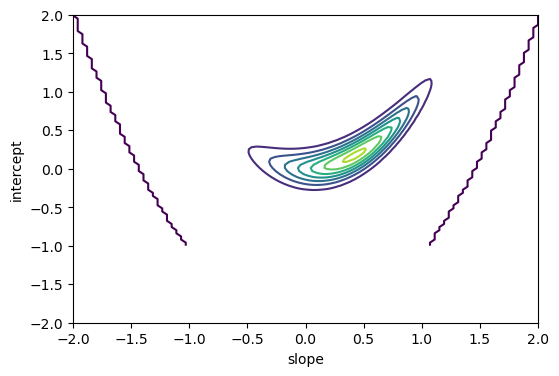

In [54]:
fig, axes = plt.subplots(1, 1, figsize=(6,4))

def log_posterior(x,y,z1,z2):
    return -(1-z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2
    
plot_distribution(ax = axes, density_fun=log_posterior, x = jnp.array([0]), y = jnp.array([0]))

## Question 5.2

In [56]:
def log_posterior(z):
    z1 = z[0]
    z2 = z[1]
    return -(1-z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2

mcmc = metropolis(log_target=log_posterior, num_params=2, num_iter = 10**4, tau = 1, theta_init= jnp.array([0,0.15]), dis_prop=0.1)

Acceptance ratio: 0.09


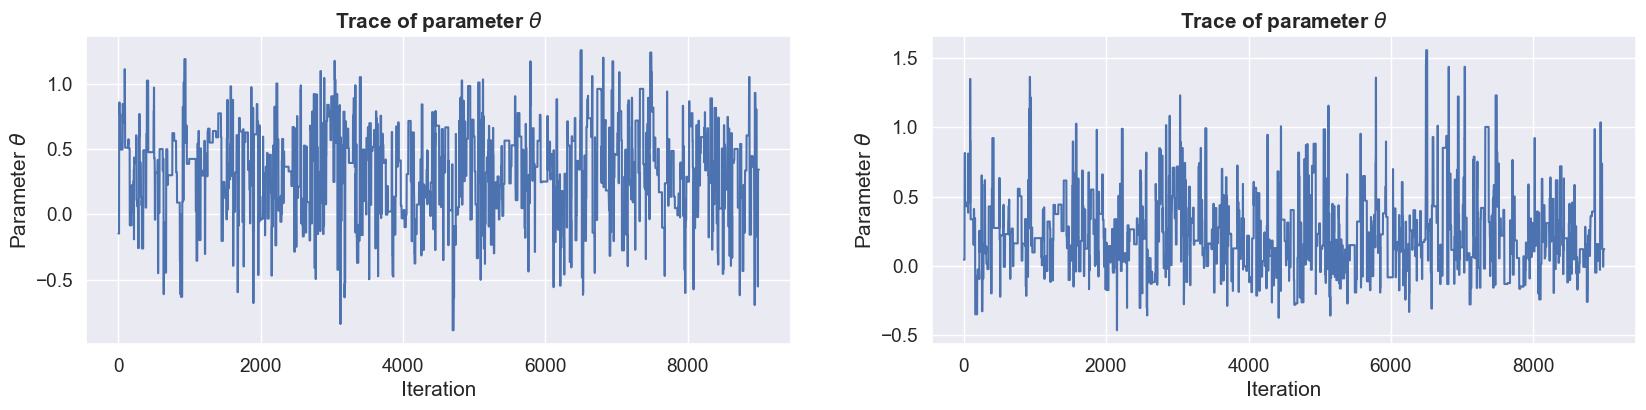

In [57]:
mcmc.plot_trace()

## Question 5.3

In [60]:
theta = mcmc.post_warmup_thetas

jnp.mean(jnp.sin(theta[:,0] * theta[:,1]))

Array(0.13883659, dtype=float32)

# Question 5.4

In [61]:
jnp.mean(theta[:,0] > theta[:,1])

Array(0.74013996, dtype=float32)